In [4]:
import cv2
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt

In [5]:
image = cv2.imread('SunriseCopernicus.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  

hist = cv2.calcHist([image], [0], None, [256], [0, 256])

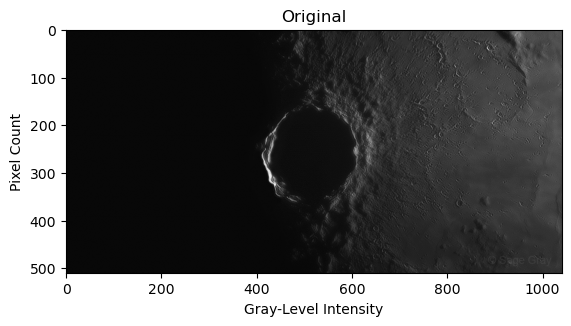

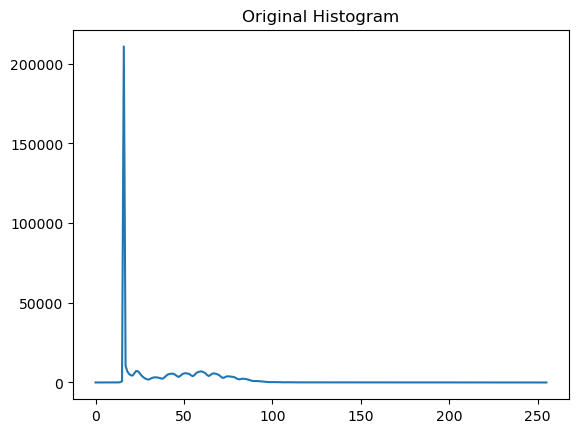

In [6]:
plt.imshow(image,cmap='gray')
plt.title("Original")
plt.xlabel("Gray-Level Intensity")
plt.ylabel("Pixel Count")
plt.show()
plt.plot(hist)
plt.title("Original Histogram")
plt.show()

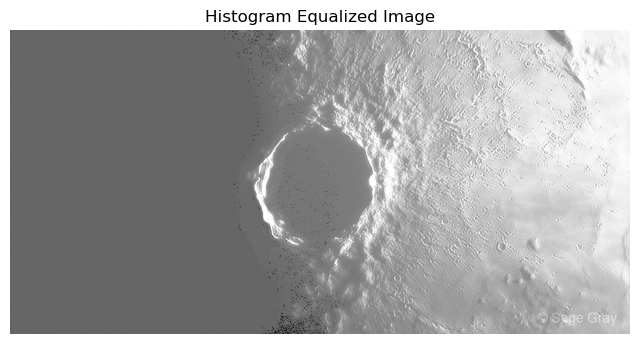

In [7]:
equalized = cv2.equalizeHist(image)

plt.figure(figsize=(8,6))
plt.imshow(equalized,cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis('off')
plt.show()

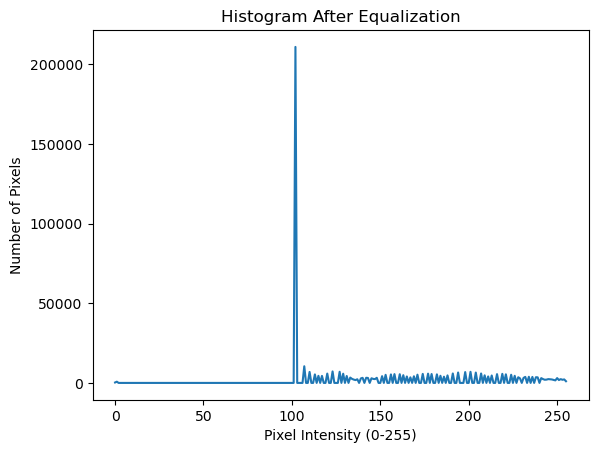

In [8]:
hist_eq = cv2.calcHist(
    [equalized],
    [0],
    None,
    [256],
    [0,256]
)

plt.plot(hist_eq)

plt.title("Histogram After Equalization")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Number of Pixels")

plt.show()

In [9]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

clahe_img = clahe.apply(image)

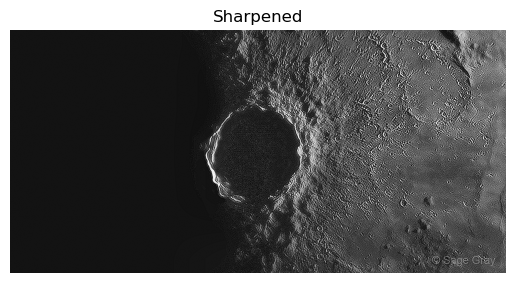

In [10]:
kernel = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
])

sharp = cv2.filter2D(clahe_img, -1, kernel)

plt.imshow(sharp,cmap='gray')
plt.title("Sharpened")
plt.axis('off')
plt.show()

blur = cv2.GaussianBlur(clahe_img,(9,9),3)

sharp = cv2.addWeighted(
    clahe_img,
    1.5,
    blur,
    -0.5,
    0
)

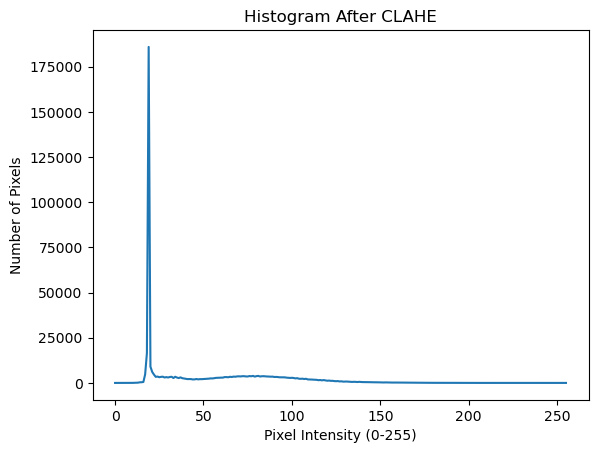

In [11]:
hist_clahe = cv2.calcHist(
    [clahe_img],
    [0],
    None,
    [256],
    [0,256]
)

plt.plot(hist_clahe)

plt.title("Histogram After CLAHE")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Number of Pixels")

plt.show()

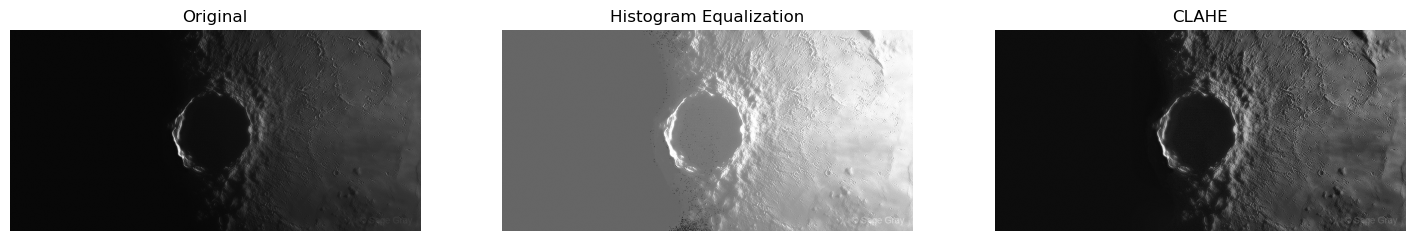

In [12]:
fig,ax = plt.subplots(1,3,figsize=(18,6))

ax[0].imshow(image,cmap='gray')
ax[0].set_title("Original")

ax[1].imshow(equalized,cmap='gray')
ax[1].set_title("Histogram Equalization")

ax[2].imshow(clahe_img,cmap='gray')
ax[2].set_title("CLAHE")

for a in ax:
    a.axis('off')

plt.show()

In [33]:
import cv2  # Import OpenCV library before using cv2 functions #Otsu Thresholding
blur = cv2.GaussianBlur(clahe_img,(5,5),0)


ret, otsu_img = cv2.threshold(
    clahe_img,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

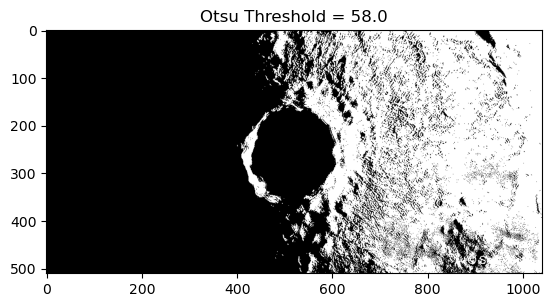

In [34]:
plt.imshow(otsu_img,cmap='gray')
plt.title(f"Otsu Threshold = {ret}")
plt.show()

In [35]:
#Contours
contours, _ = cv2.findContours(
    otsu_img,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

In [36]:
print("Number of contours detected:", len(contours))

Number of contours detected: 451


In [37]:
filtered_contours = []

for c in contours:
    area = cv2.contourArea(c)
    if area > 100:
        filtered_contours.append(c)

print("Filtered contours:", len(filtered_contours))

Filtered contours: 14


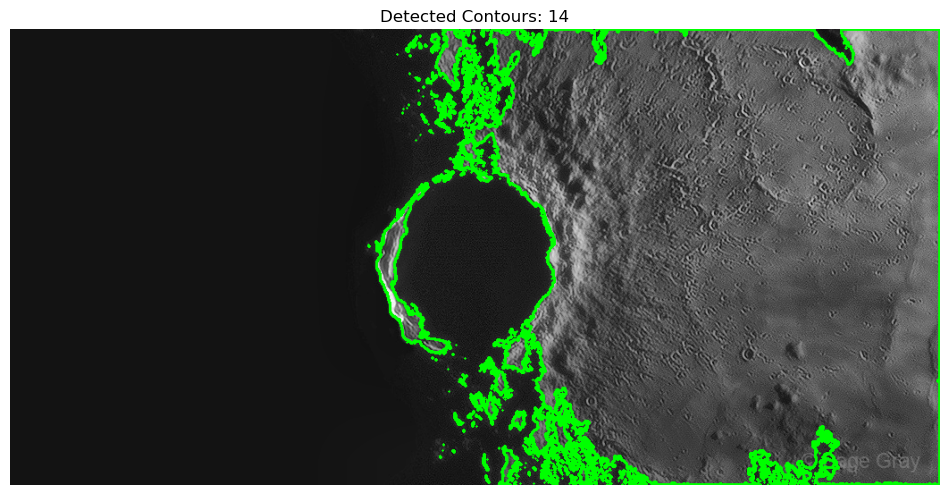

In [38]:
cv2.drawContours(
    img_color,
    filtered_contours,
    -1,
    (0,255,0),
    2
)

plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Contours: {len(filtered_contours)}")
plt.axis('off')
plt.show()

In [39]:
for i, c in enumerate(filtered_contours):
    area = cv2.contourArea(c)
    print(f"Contour {i+1}: Area = {area:.2f} pixels")

Contour 1: Area = 104.50 pixels
Contour 2: Area = 365.50 pixels
Contour 3: Area = 149.50 pixels
Contour 4: Area = 627.50 pixels
Contour 5: Area = 505.50 pixels
Contour 6: Area = 170.00 pixels
Contour 7: Area = 213.50 pixels
Contour 8: Area = 3167.50 pixels
Contour 9: Area = 519.50 pixels
Contour 10: Area = 166.50 pixels
Contour 11: Area = 150.00 pixels
Contour 12: Area = 120.00 pixels
Contour 13: Area = 226238.50 pixels
Contour 14: Area = 1200.50 pixels
